##### функция для вывода ARIMA

In [254]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

def print_arima(results):
    """
    Печатает уравнение ARIMA модели на основе объекта results из statsmodels.
    Поддерживает модели с константой и без, порядки p, d, q.
    """
    # Получаем порядки модели
    p, d, q = results.model.order
    params = results.params

    # Левая часть в зависимости от d
    if d == 0:
        lhs = "y_t"
    elif d == 1:
        lhs = "Δy_t   (где Δy_t = y_t - y_{t-1})"
    else:
        lhs = f"Δ^{d}y_t"

    # Собираем правую часть
    rhs_parts = []

    # Константа (если есть)
    if 'const' in params:
        const_val = params['const']
        rhs_parts.append(f"{const_val:.4f}")

    # AR-коэффициенты
    for lag in range(1, p + 1):
        coef_name = f'ar.L{lag}'
        if coef_name in params and abs(params[coef_name]) > 1e-8:
            coef = params[coef_name]
            sign = "+" if coef >= 0 else "-"
            rhs_parts.append(f"{sign} {abs(coef):.4f} y_{{t-{lag}}}")

    # MA-коэффициенты
    for lag in range(1, q + 1):
        coef_name = f'ma.L{lag}'
        if coef_name in params and abs(params[coef_name]) > 1e-8:
            coef = params[coef_name]
            sign = "+" if coef >= 0 else "-"
            rhs_parts.append(f"{sign} {abs(coef):.4f} ε_{{t-{lag}}}")

    # Текущий шум
    rhs_parts.append("+ ε_t")

    # Собираем всё в строку, убираем лишние знаки
    rhs = " ".join(rhs_parts)
    # Заменяем "+ -" на "- " и убираем начальный плюс, если он есть
    rhs = rhs.replace("+ -", "- ").replace("+ +", "+ ")
    if rhs.startswith("+ "):
        rhs = rhs[2:]

    # Выводим уравнение
    print(f"{lhs} = {rhs}")


# Загружаю данные

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [41]:
data = pd.read_excel('ARIMA_example.xlsx')
data.head()

,y1,y2,y3
0,19.916475,5.007638,1.000000
1,19.980078,4.983601,0.899422
2,19.857470,5.024198,0.750124
3,19.953421,5.055578,0.802100
4,20.114684,5.214623,0.637604


# Модель для ряда 1

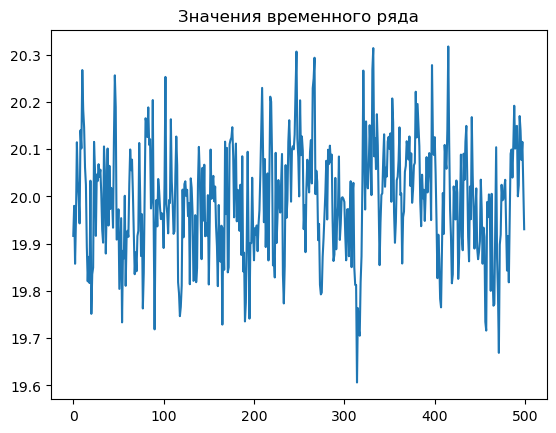

In [161]:
y1 = data['y1']
plt.plot(y1)
plt.title('Значения временного ряда')
plt.show()

### Тесты на стационарность

In [170]:
from statsmodels.tsa.stattools import adfuller, kpss 
adf_pvalue = adfuller(y1)[1]
print(f'p-value для теста Дики-Фуллера: {adf_pvalue}')

kpss_pvalue = kpss(y1)[1]
print(f'p-value для теста KPSS: {kpss_pvalue}')

print('\nДля теста Дики-Фуллера p-value сильно < 0.05, a p-value для теста KPSS гораздо > 0.05')
print('Следовательно, делаем вывод о стационарности ряда!')

p-value для теста Дики-Фуллера: 1.8984743797587374e-22
p-value для теста KPSS: 0.1

Для теста Дики-Фуллера p-value сильно < 0.05, a p-value для теста KPSS гораздо > 0.05
Следовательно, делаем вывод о стационарности ряда!


C:\Users\Pilch\AppData\Local\Temp\ipykernel_17304\3007954632.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_pvalue = kpss(y1)[1]


### Анализ ACF и PACF для подбора (p, d, q)

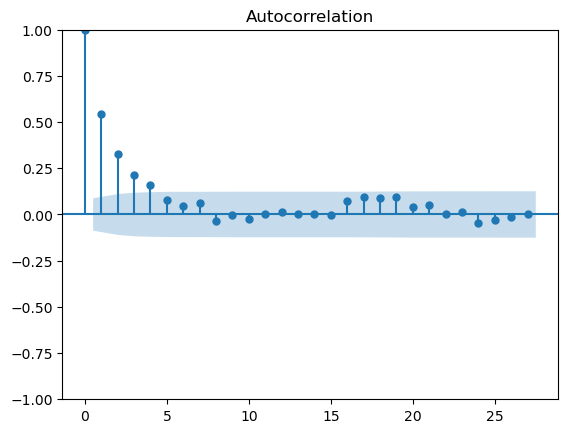

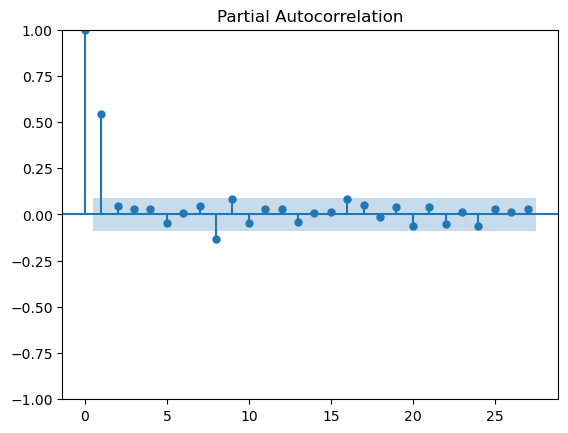

In [38]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(y1)
plot_pacf(y1)
plt.show()

In [175]:
print('Видим, что на ACF ряд плавно затухает, а на PACF обрывается после лага 1.')
print('Следовательно, (p=1, d=0, q=0). Предполагаем процесс AR(1)')

Видим, что на ACF ряд плавно затухает, а на PACF обрывается после лага 1.
Следовательно, (p=1, d=0, q=0). Предполагаем процесс AR(1)


### Построение и диагностика модели ARIMA(1,0,0)

In [244]:
from statsmodels.tsa.arima.model import ARIMA
model1 = ARIMA(y1, order=(1, 0, 0))
fitted_model1 = model1.fit()
fitted_model1.params

const     19.990966
ar.L1      0.543614
sigma2     0.009924
dtype: float64

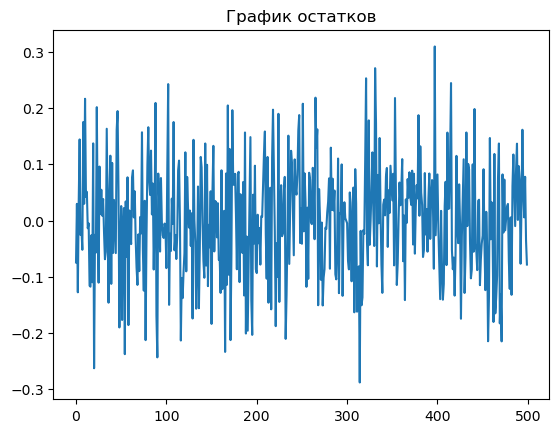

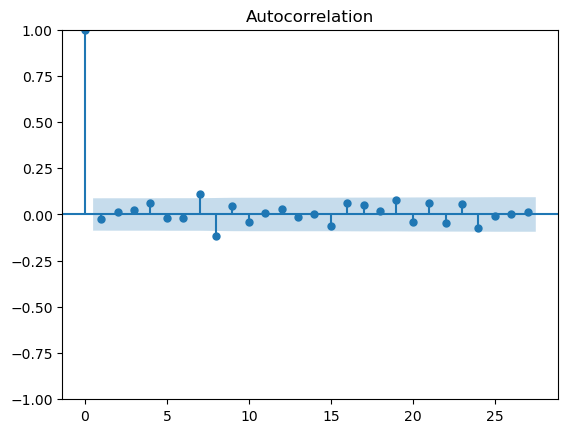

In [245]:
resid = fitted_model1.resid
plt.plot(resid)
plt.title("График остатков")
plot_acf(resid)
plt.show()

In [246]:
print(fitted_model1.summary())

                               SARIMAX Results                                
Dep. Variable:                     y1   No. Observations:                  500
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 443.531
Date:                Tue, 10 Mar 2026   AIC                           -881.063
Time:                        20:51:00   BIC                           -868.419
Sample:                             0   HQIC                          -876.102
                                - 500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.9910      0.010   2048.889      0.000      19.972      20.010
ar.L1          0.5436      0.039     13.790      0.000       0.466       0.621
sigma2         0.0099      0.001     15.347      0.0

In [205]:
print(f'ВЫВОДЫ:\n\n'
      f'1. Коэффициент значим для alpha=0.05\n'
      f'2. Тест Льюнга-Бокса > 0.05 => остатки - белый шум\n'
      f'3. Тест Жарка-Бера > 0.05 => остатки нормальны\n'
      f'4. AIC = {fitted_model1.aic:.3f}, BIC = {fitted_model1.bic:.3f}')

ВЫВОДЫ:

1. Коэффициент значим для alpha=0.05
2. Тест Льюнга-Бокса > 0.05 => остатки - белый шум
3. Тест Жарка-Бера > 0.05 => остатки нормальны
4. AIC = -881.063, BIC = -868.419


#### Вывод: модель довольно точная, но попробую диффиренцировать!

### Построение и диагностика модели ARIMA(1, 1, 0)

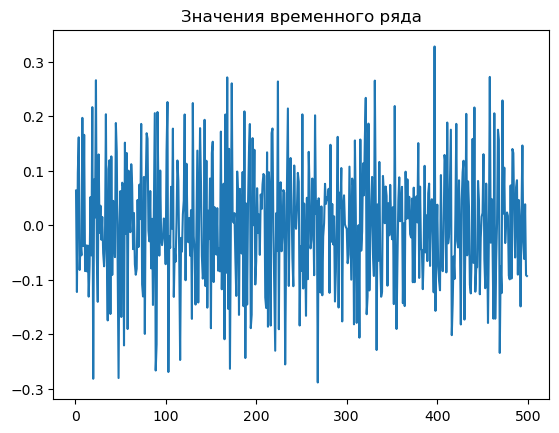

In [209]:
y1_diff = y1.diff()
plt.plot(y1_diff)
plt.title('Значения временного ряда')
plt.show()

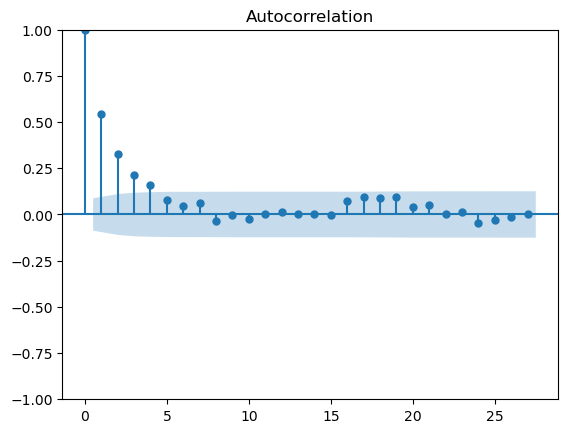

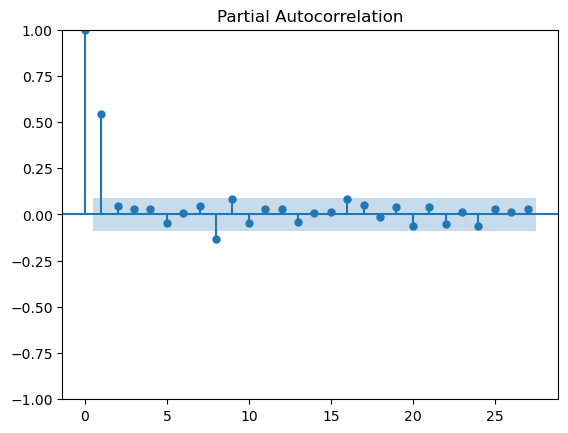

In [212]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(y1)
plot_pacf(y1)
plt.show()

In [213]:
print('В целом все так же, только визуально стационарность стала видна намного лучше')

В целом все так же, только визуально стационарность стала видна намного лучше


In [223]:
from statsmodels.tsa.arima.model import ARIMA
model2 = ARIMA(y1, order=(1, 1, 0))
fitted_model2 = model2.fit()
fitted_model2.params

ar.L1    -0.260977
sigma2    0.011994
dtype: float64

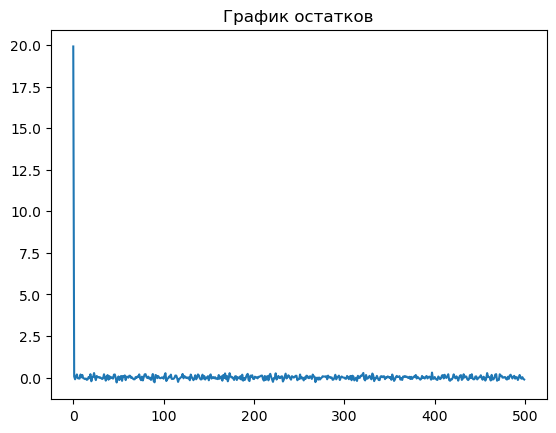

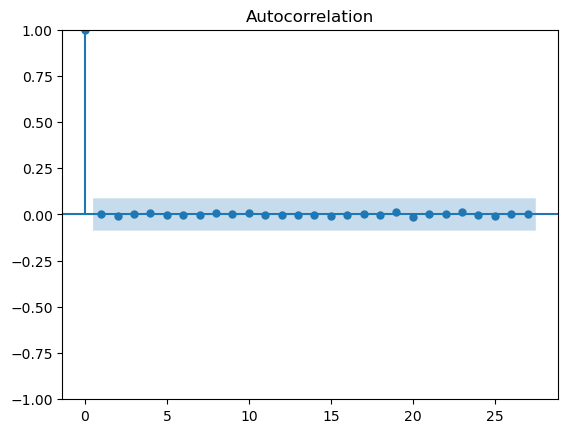

In [216]:
resid = fitted_model1.resid
plt.plot(resid)
plt.title("График остатков")
plot_acf(resid)
plt.show()

In [220]:
print('На графиках остатков мы видим, что в разы уменьшилась корелляция на всех лагах, снизилась дисперсия остатков!')

На графиках остатков мы видим, что в разы уменьшилась корелляция на всех лагах, снизилась дисперсия остатков!


In [224]:
print(fitted_model2.summary())

                               SARIMAX Results                                
Dep. Variable:                     y1   No. Observations:                  500
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 395.526
Date:                Tue, 10 Mar 2026   AIC                           -787.053
Time:                        20:45:45   BIC                           -778.628
Sample:                             0   HQIC                          -783.747
                                - 500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2610      0.043     -6.056      0.000      -0.345      -0.177
sigma2         0.0120      0.001     14.815      0.000       0.010       0.014
Ljung-Box (L1) (Q):                   1.35   Jarque-

#### Вывод: модель с d=1 работает чуть лучше, оставляем ее!

### Построение прогноза

In [234]:
final_model = fitted_model2
forecast = fitted_model2.forecast(steps=20)
forecast

500    19.954884
501    19.948532
502    19.950190
503    19.949757
504    19.949870
505    19.949841
506    19.949848
507    19.949846
508    19.949847
509    19.949847
510    19.949847
511    19.949847
512    19.949847
513    19.949847
514    19.949847
515    19.949847
516    19.949847
517    19.949847
518    19.949847
519    19.949847
Name: predicted_mean, dtype: float64

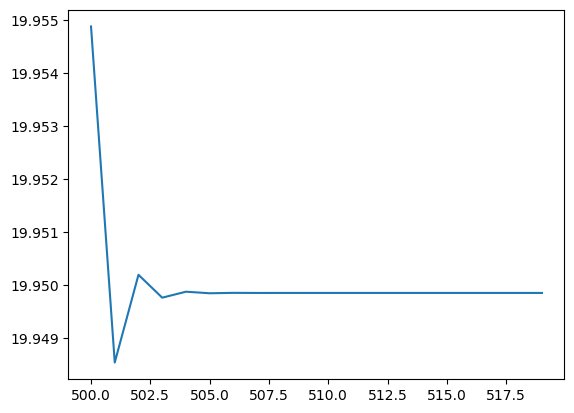

In [235]:
plt.plot(forecast)
plt.show()

In [237]:
print('По странному графику можем предположить, что модель переобучилась на исходных данных.')
print('Попробуем оставить модель без диффиренцирования')

По странному графику можем предположить, что модель переобучилась на исходных данных.
Попробуем оставить модель без диффиренцирования


In [247]:
final_model = fitted_model1
forecast = fitted_model1.forecast(steps=10)
forecast

500    19.958121
501    19.973111
502    19.981260
503    19.985690
504    19.988098
505    19.989407
506    19.990118
507    19.990505
508    19.990716
509    19.990830
Name: predicted_mean, dtype: float64

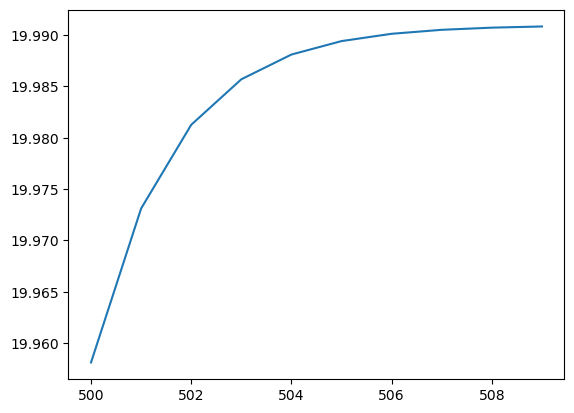

In [248]:
plt.plot(forecast)
plt.show()

In [255]:
print('График прогнозов плавно возрастает, что соотвествует здравому смыслу. Модель построена!')
print_arima(final_model)

График прогнозов плавно возрастает, что соотвествует здравому смыслу. Модель построена!
y_t = 19.9910 + 0.5436 y_{t-1} + ε_t


# Модель для ряда 2

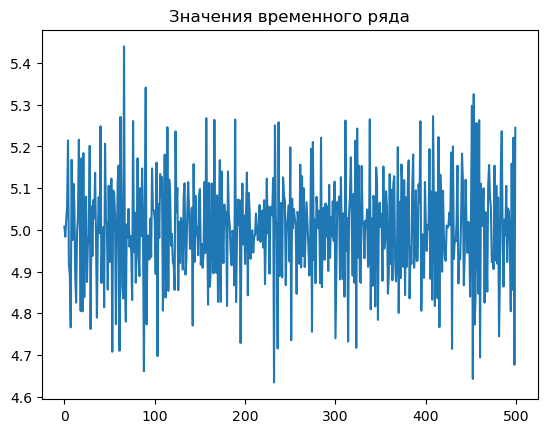

In [317]:
y2 = data['y2']
plt.plot(y2)
plt.title('Значения временного ряда')
plt.show()

### Тесты на стационарность

In [318]:
from statsmodels.tsa.stattools import adfuller, kpss 
adf_pvalue = adfuller(y2)[1]
print(f'p-value для теста Дики-Фуллера: {adf_pvalue}')

kpss_pvalue = kpss(y2)[1]
print(f'p-value для теста KPSS: {kpss_pvalue}')

print('\nДля теста Дики-Фуллера p-value сильно < 0.05, a p-value для теста KPSS так же немного < 0.05')
print('Видим противоречие, проверим с помощью графиков!')

p-value для теста Дики-Фуллера: 9.198303612496336e-24
p-value для теста KPSS: 0.041666666666668

Для теста Дики-Фуллера p-value сильно < 0.05, a p-value для теста KPSS так же немного < 0.05
Видим противоречие, проверим с помощью графиков!


### Анализ ACF и PACF

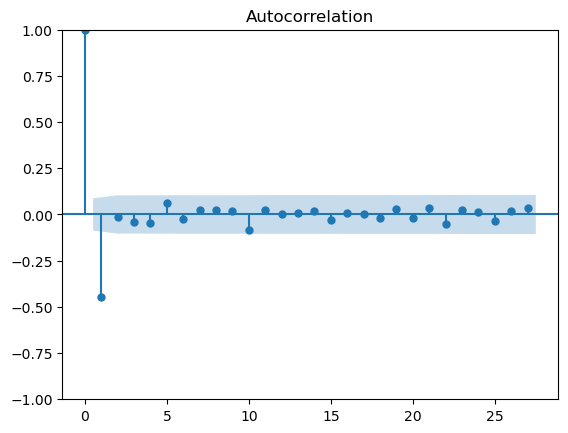

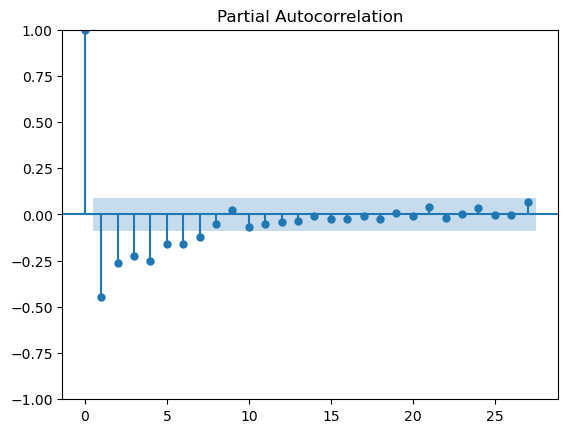

In [319]:
plot_acf(y2)
plot_pacf(y2)
plt.show()

In [320]:
print('Тесты напоминают вид MA(1). В любом случае, попробуем диффиренцировать')

Тесты напоминают вид MA(1). В любом случае, попробуем диффиренцировать


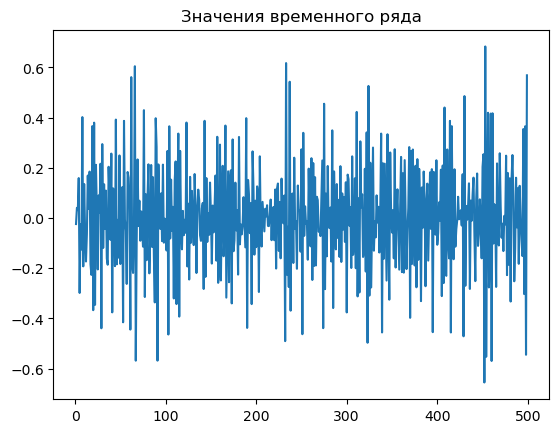

In [321]:
y2_diff = y2.diff().dropna()
plt.plot(y2_diff)
plt.title('Значения временного ряда')
plt.show()

In [322]:
from statsmodels.tsa.stattools import adfuller, kpss 
adf_pvalue = adfuller(y2_diff)[1]
print(f'p-value для теста Дики-Фуллера: {adf_pvalue}')

kpss_pvalue = kpss(y2_diff)[1]
print(f'p-value для теста KPSS: {kpss_pvalue}')

print('\nДля теста Дики-Фуллера p-value сильно < 0.05, a p-value для теста KPSS намного > 0.05')
print('Теперь тесты дают однозначные показания. Делаем вывод о стационарности ряда!')

p-value для теста Дики-Фуллера: 5.731153098624329e-18
p-value для теста KPSS: 0.1

Для теста Дики-Фуллера p-value сильно < 0.05, a p-value для теста KPSS намного > 0.05
Теперь тесты дают однозначные показания. Делаем вывод о стационарности ряда!


C:\Users\Pilch\AppData\Local\Temp\ipykernel_17304\3123032141.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_pvalue = kpss(y2_diff)[1]


In [323]:
print('Будем работать с диффиренцированным рядом.')
print('Итого: p=0, d=1, q=1')

Будем работать с диффиренцированным рядом.
Итого: p=0, d=1, q=1


### Построение и диагностика модели ARIMA(0, 1, 1)

In [324]:
from statsmodels.tsa.arima.model import ARIMA
model1 = ARIMA(y2, order=(0, 1, 1))
fitted_model1 = model1.fit()
fitted_model1.params

C:\Users\Pilch\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ma.L1    -0.999984
sigma2    0.016524
dtype: float64

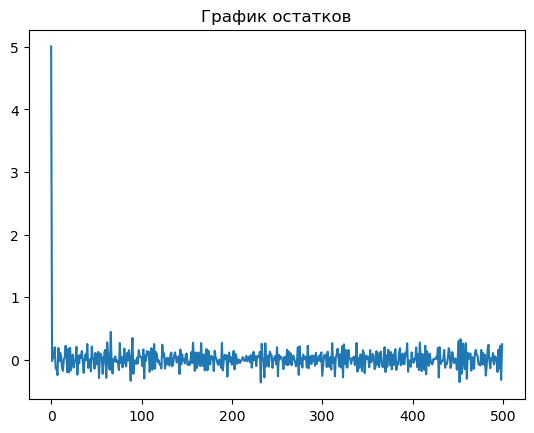

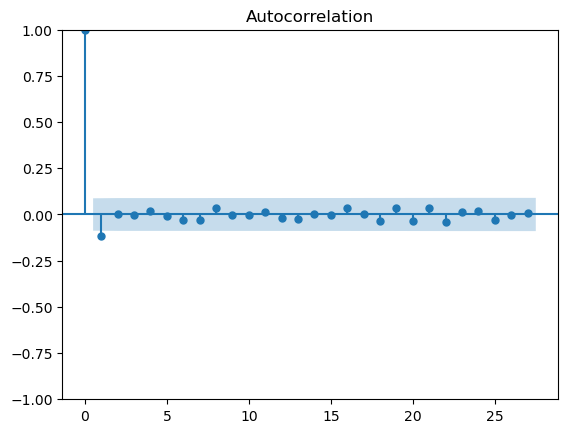

In [325]:
resid = fitted_model1.resid
plt.plot(resid)
plt.title("График остатков")
plot_acf(resid)
plt.show()

In [326]:
print(fitted_model1.summary())

                               SARIMAX Results                                
Dep. Variable:                     y2   No. Observations:                  500
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 312.513
Date:                Wed, 11 Mar 2026   AIC                           -621.027
Time:                        19:32:17   BIC                           -612.601
Sample:                             0   HQIC                          -617.720
                                - 500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.0000      6.122     -0.163      0.870     -12.999      10.999
sigma2         0.0165      0.101      0.163      0.870      -0.182       0.215
Ljung-Box (L1) (Q):                  99.77   Jarque-

In [327]:
print('В нашей модели коэффициент совсем незначим, да и в целом имеет неадекватное значение.')
print('Хоть отстатки некоррелированны и стремятся к нулю, нужно менять модель!')

В нашей модели коэффициент совсем незначим, да и в целом имеет неадекватное значение.
Хоть отстатки некоррелированны и стремятся к нулю, нужно менять модель!


#### Вывод: пробуем обучить модель без диффиренцирования

### Построение и диагностика модели ARIMA(0, 0, 1)

In [328]:
from statsmodels.tsa.arima.model import ARIMA
model2 = ARIMA(y2, order=(0, 0, 1))
fitted_model2 = model2.fit()
fitted_model2.params

const     5.000864
ma.L1    -0.829798
sigma2    0.010358
dtype: float64

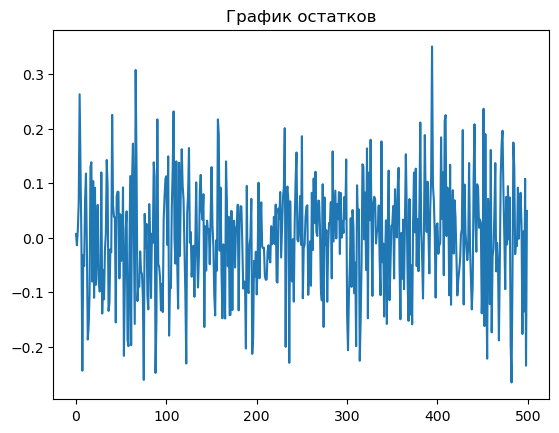

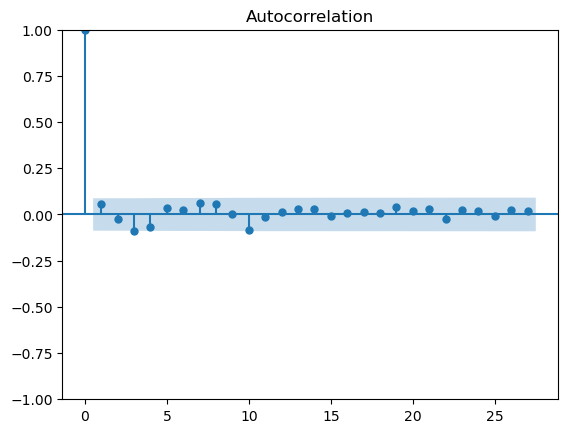

In [329]:
resid = fitted_model2.resid
plt.plot(resid)
plt.title("График остатков")
plot_acf(resid)
plt.show()

In [330]:
print(fitted_model2.summary())

                               SARIMAX Results                                
Dep. Variable:                     y2   No. Observations:                  500
Model:                 ARIMA(0, 0, 1)   Log Likelihood                 432.419
Date:                Wed, 11 Mar 2026   AIC                           -858.838
Time:                        19:32:20   BIC                           -846.194
Sample:                             0   HQIC                          -853.876
                                - 500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0009      0.001   6373.145      0.000       4.999       5.002
ma.L1         -0.8298      0.026    -31.728      0.000      -0.881      -0.779
sigma2         0.0104      0.001     15.722      0.0

Выводы: 
1. Коэффициент значим
2. Корреляция отсутствует по тесту Льюнга-Бокса: модель нашла все необходимые зависимости в данных
3. Относительно модели с диффиренцированием тесты AIC и BIC намного лучше

#### Вывод: используем эту модель для предсказаний

### Построение прогноза

In [358]:
final_model = fitted_model2
forecast = final_model.forecast()
forecast

array([4.96011208])

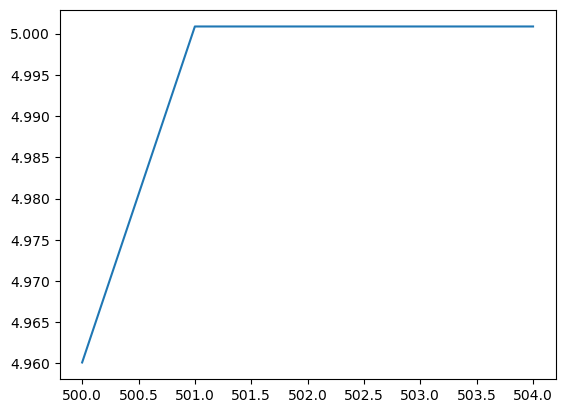

In [349]:

plt.plot(forecast)
plt.show()

In [350]:
print('Видим, что только первое значение кооректное, а астальные равны мат.ожиданию.')
print('Это классический пример предсказаний для скользящего среднего!')

Видим, что только первое значение кооректное, а астальные равны мат.ожиданию.
Это классический пример предсказаний для скользящего среднего!


In [359]:
print(f'Итоговый прогноз = {final_model.forecast().values[0]}')

Итоговый прогноз = 4.960112076242848


In [361]:
print('Итоговая модель:')
print_arima(final_model)

Итоговая модель:
y_t = 5.0009 - 0.8298 ε_{t-1} + ε_t


# Модель для ряда 3

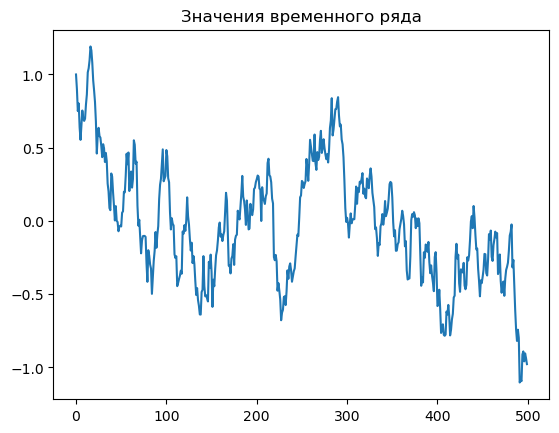

In [363]:
y3 = data['y3']
plt.plot(y3)
plt.title('Значения временного ряда')
plt.show()

### Тесты на стационарность

In [368]:
print('По графику сразу видим, что ряд нестационарен. Скорее всего есть тренд. Попробуем взять разность!')

По графику сразу видим, что ряд нестационарен. Скорее всего есть тренд. Попробуем взять разность!


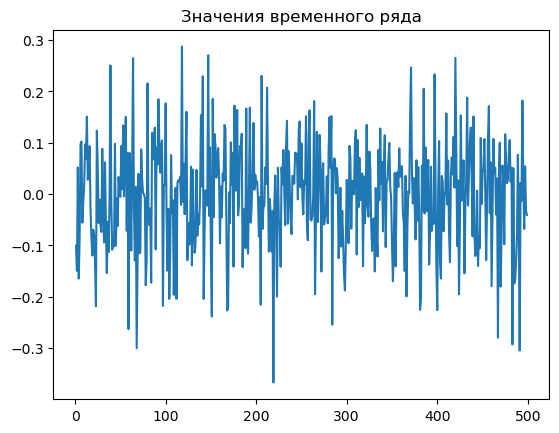

In [460]:
y3_diff = y3.diff().dropna()
plt.plot(y3_diff)
plt.title('Значения временного ряда')
plt.show()

In [417]:
from statsmodels.tsa.stattools import adfuller, kpss 
adf_pvalue = adfuller(y3_diff)[1]
print(f'p-value для теста Дики-Фуллера: {adf_pvalue}')

kpss_pvalue = kpss(y3_diff)[1]
print(f'p-value для теста KPSS: {kpss_pvalue}')

p-value для теста Дики-Фуллера: 0.0
p-value для теста KPSS: 0.1


C:\Users\Pilch\AppData\Local\Temp\ipykernel_17304\1183482264.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_pvalue = kpss(y3_diff)[1]


In [418]:
print('В целом оба теста говорят о стационарности ряда, так что будем работать с ним.')

В целом оба теста говорят о стационарности ряда, так что будем работать с ним.


### Анализ ACF и PACF

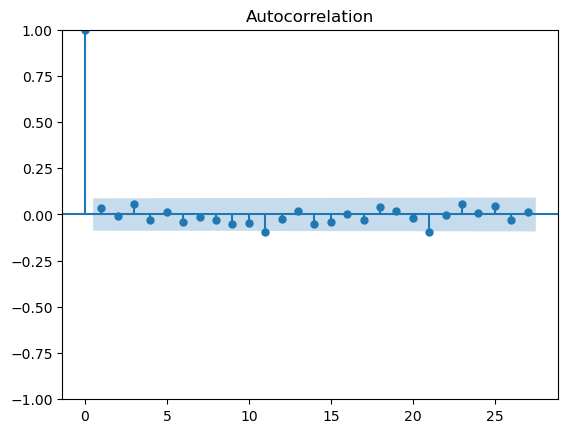

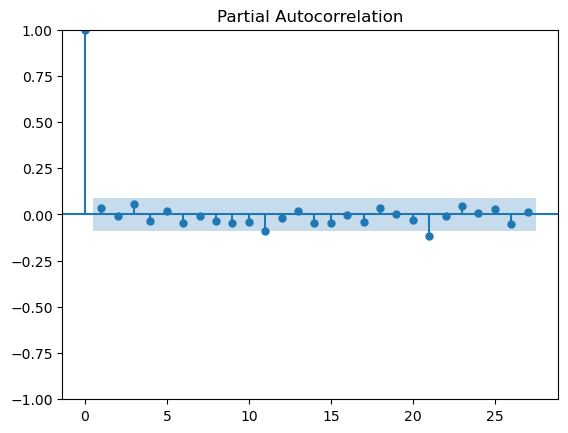

In [453]:
plot_acf(y3_diff)
plot_pacf(y3_diff)
plt.show()

In [459]:
print('Видим, что ряд - случайное блуждание. Следовательно, построим соответствующую модель')

Видим, что ряд - случайное блуждание. Следовательно, построим соответствующую модель


### Построение и диагностика модели ARIMA(0, 1, 0)

In [461]:
from statsmodels.tsa.arima.model import ARIMA
model1 = ARIMA(y3, order=(0, 1, 0), trend='n')
fitted_model1 = model1.fit()
fitted_model1.params

sigma2    0.010704
dtype: float64

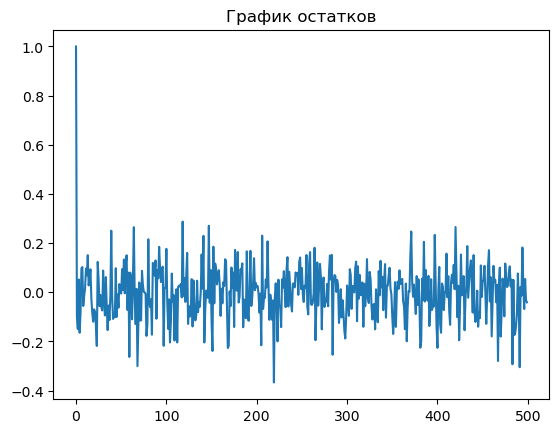

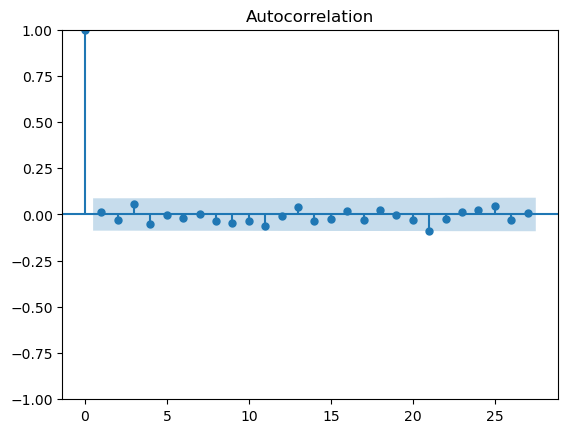

In [462]:
resid = fitted_model1.resid
plt.plot(resid)
plt.title("График остатков")
plot_acf(resid)
plt.show()

In [463]:
print(fitted_model1.summary())

                               SARIMAX Results                                
Dep. Variable:                     y3   No. Observations:                  500
Model:                 ARIMA(0, 1, 0)   Log Likelihood                 423.941
Date:                Tue, 31 Mar 2026   AIC                           -845.882
Time:                        11:31:42   BIC                           -841.670
Sample:                             0   HQIC                          -844.229
                                - 500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0107      0.001     17.019      0.000       0.009       0.012
Ljung-Box (L1) (Q):                   0.69   Jarque-Bera (JB):                 4.46
Prob(Q):                              0.41   Pr

Выводы:
1. Наша модель - модель случайного блуждания
2. Тест Льюнга-Бокса показал отсутствие автокорреляции у остатков
3. Есть нормальность остатков, круто, наверное :)
4. По AIC и BIC показатели небольшие, это тоже хорошо. Но размер -  не главное!

#### Вывод используем модель для предсказаний. Прогнозом будет последнее значение

### Построение прогноза

In [468]:
final_model = fitted_model1
forecast = final_model.forecast(steps=10)
forecast

500   -0.977116
501   -0.977116
502   -0.977116
503   -0.977116
504   -0.977116
505   -0.977116
506   -0.977116
507   -0.977116
508   -0.977116
509   -0.977116
Name: predicted_mean, dtype: float64

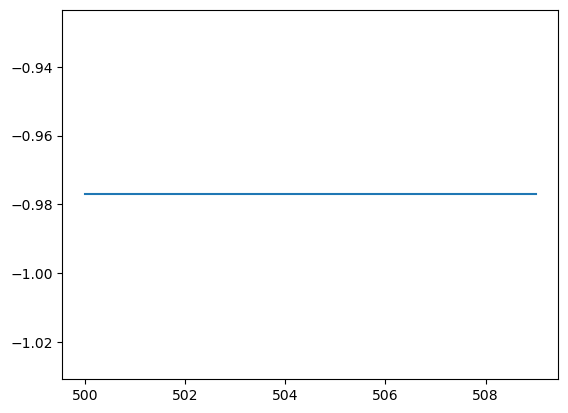

In [469]:
plt.plot(forecast)
plt.show()

In [470]:
print('График логичен для модели случайного блуждания!')
print('\nФинальная модель:')
print_arima(final_model)

График логичен для модели случайного блуждания!

Финальная модель:
Δy_t   (где Δy_t = y_t - y_{t-1}) = ε_t
